In [1]:
#import libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [2]:
#load the dataset
df = pd.read_csv('diabetes.csv')

In [3]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
#pre processing

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [7]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [8]:
df.duplicated().sum()

0

<Axes: xlabel='Outcome'>

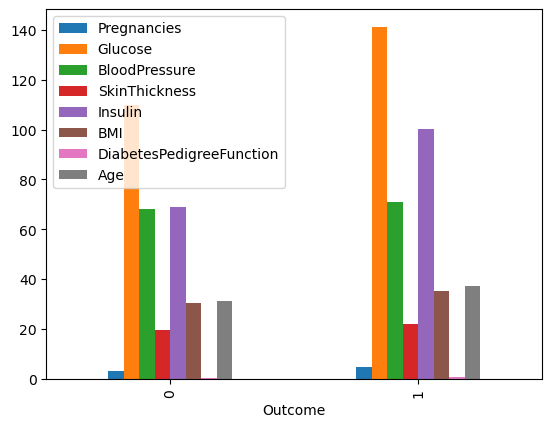

In [9]:
df.groupby('Outcome').mean().plot(kind = 'bar')

In [10]:
X = df.drop(columns = 'Outcome',axis = 1)
y = df['Outcome']

In [11]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state=42)

In [12]:
scaler = StandardScaler()
scaler.fit_transform(X_train)

array([[-0.52639686, -1.15139792, -3.75268255, ..., -4.13525578,
        -0.49073479, -1.03594038],
       [ 1.58804586, -0.27664283,  0.68034485, ..., -0.48916881,
         2.41502991,  1.48710085],
       [-0.82846011,  0.56687102, -1.2658623 , ..., -0.42452187,
         0.54916055, -0.94893896],
       ...,
       [ 1.8901091 , -0.62029661,  0.89659009, ...,  1.76054443,
         1.981245  ,  0.44308379],
       [-1.13052335,  0.62935353, -3.75268255, ...,  1.34680407,
        -0.78487662, -0.33992901],
       [-1.13052335,  0.12949347,  1.43720319, ..., -1.22614383,
        -0.61552223, -1.03594038]])

In [13]:
scaler.fit_transform(X_test)

array([[ 0.49124165, -0.72667791, -0.44147615, ...,  0.23374785,
        -0.17094071,  0.66661154],
       [-0.63368347, -0.28534901,  0.31890843, ...,  0.43537945,
        -1.08608042, -1.07335756],
       [-0.63368347, -0.41144298, -0.17310512, ..., -0.14579397,
        -1.05362866, -1.07335756],
       ...,
       [ 1.05370422, -0.82124838,  0.18472291, ...,  0.56584695,
         0.00754398,  1.77386461],
       [-0.63368347,  0.78644972,  0.09526591, ..., -0.47789306,
        -0.47274211, -0.44064153],
       [ 1.05370422, -1.48324172,  0.09526591, ...,  0.38793672,
         0.72148276,  0.35025352]])

In [14]:
from sklearn import svm

In [15]:
#training the model

In [16]:
svmclassifier = svm.SVC(kernel = 'linear')
svmclassifier.fit(X_train,y_train)

SVC(kernel='linear')

In [17]:
#evaluate the model
y_pred = svmclassifier.predict(X_test)
accuracy = accuracy_score(y_pred,y_test)
print('the accuracy score of the model is:',accuracy * 100)

the accuracy score of the model is: 75.32467532467533


In [18]:
logmodel = LogisticRegression()
logmodel.fit(X_train,y_train)

C:\Users\Motheo Moshageng\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [19]:
y_pred = logmodel.predict(X_test)
accuracy = accuracy_score(y_pred,y_test)
print('the accuracy of the model is:', accuracy * 100)

the accuracy of the model is: 74.67532467532467


In [20]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [21]:
#making a predictive system 

input_data = (6,148,72,35,0,33.6,0.627,50,)
#changing input dta into an aaray
input_data_array = np.array(input_data)

#reshape the array as we are predicting for one instance
input_data_reshaped = input_data_array.reshape(1,-1)

In [22]:
#standadize the input data
std_data = scaler.transform(input_data_reshaped)
print(std_data)

[[ 0.49124165  0.84949671  0.18472291  0.77931431 -0.66022144  0.18630513
   0.46835901  1.22023807]]


C:\Users\Motheo Moshageng\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [23]:
prediction = svmclassifier.predict(std_data)
print(prediction)

[0]


C:\Users\Motheo Moshageng\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


In [24]:
prediction1 = logmodel.predict(std_data)
print(prediction1)

[0]


C:\Users\Motheo Moshageng\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [25]:
if (prediction[0] == 0):
    print('the person is not diabetic')
else:
    print('the person is diabetic')

the person is not diabetic


In [26]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [27]:
#making a predictive system 

input_data = (0,137,40,35,168,43.1,2.288,33)
#changing input dta into an aaray
input_data_array = np.array(input_data)

#reshape the array as we are predicting for one instance
input_data_reshaped = input_data_array.reshape(1,-1)


#standadize the input data
std_data = scaler.transform(input_data_reshaped)
print(std_data)

#output
prediction = svmclassifier.predict(std_data)
print(prediction)

#result outcome
if (prediction[0] == 0):
    print('the person is not diabetic')
else:
    print('the person is diabetic')

[[-1.19614603  0.50273829 -1.24658922  0.77931431  0.85367107  1.3130699
   5.85859681 -0.12428351]]
[0]
the person is not diabetic


C:\Users\Motheo Moshageng\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\Motheo Moshageng\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


In [28]:
#saving the model

In [29]:
import pickle

In [30]:
filename = 'diabetes_model.sav'    #file that is going to  be used in the API
pickle.dump(svmclassifier,open(filename,'wb'))

In [31]:
#loading the saved model
loaded_model = pickle.load(open('diabetes_model.sav','rb'))

In [32]:
for column in X.columns:
    print(column)

Pregnancies
Glucose
BloodPressure
SkinThickness
Insulin
BMI
DiabetesPedigreeFunction
Age


In [33]:
#pip install fastapi,uvicorn,json,pickle,sckit-learn,requests,pydantic

In [34]:
pickle.dump(svmclassifier,open('svmclassifier.pkl','wb'))

In [35]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')